# Model Training 

**Objective**: Train a model to predict unconstrained train demand given:
- `day_x` (days before departure)
- `price` (offered ticket price)  
- Additional contextual features

**Business Goal**: Optimize revenue (price × demand)

---

## Key Approach: Temporal Split

**Training Strategy**:
- **Train**: Old trains (departure_date < 2020-01-01) with ALL their day_x observations
- **Validate**: New trains (departure_date >= 2020-01-01) with ALL their day_x observations
- **Learn**: General demand patterns that transfer to future trains

**Why?**
- Simulates real deployment: predict demand for NEW trains using patterns from PAST trains
- Avoids data leakage: no future information used to predict past
- Model learns: "How does demand behave for trains in general?"

**Model Function**:
```python
predict_demand(day_x, price, route, departure_time, ...) → predicted_demand
```

Can predict for ANY train at ANY day_x from -89 to -1.


|Approche|Adapté ici ?|Pourquoi | 
|------|----------|-------------|
LSTM / séquentiel|⚠️ Possible mais compliqué| Séries courtes, besoin de conditionner sur le prix
Régression tabulaire (XGBoost, LightGBM)|✅ Recommandé| Gère naturellement f(day_x, price, features...)
Régression + features temporelles|✅ Idéal|Le meilleur des deux mondes
Causal Forecasting (Orthogonal Learning) — [le papier](https://arxiv.org/pdf/2411.00126) |✅ Le plus adapté au vrai problème|Isole l'effet causal du prix sur la demande, robuste OOD

## 1. Imports and Setup

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ Imports complete")
print(f"LightGBM version: {lgb.__version__}")

✓ Imports complete
LightGBM version: 4.6.0


## 2. Data Loading

In [2]:
# Load datasets
train_df = pd.read_parquet("cayzn_train.parquet")
test_df = pd.read_parquet("cayzn_test.parquet")

# Convert date strings to datetime (needed for temporal split)
train_df['departure_date'] = pd.to_datetime(train_df['departure_date'])
train_df['sale_date'] = pd.to_datetime(train_df['sale_date'])

test_df['departure_date'] = pd.to_datetime(test_df['departure_date'])
test_df['sale_date'] = pd.to_datetime(test_df['sale_date'])

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

# Analyze date ranges
print(f"\n=== Training Data Time Range ===")
print(f"Departure dates: {train_df['departure_date'].min().date()} to {train_df['departure_date'].max().date()}")
print(f"Sale dates: {train_df['sale_date'].min().date()} to {train_df['sale_date'].max().date()}")

print(f"\n=== Test Data Time Range ===")
print(f"Departure dates: {test_df['departure_date'].min().date()} to {test_df['departure_date'].max().date()}")
print(f"Sale dates: {test_df['sale_date'].min().date()} to {test_df['sale_date'].max().date()}")

Train shape: (632841, 30)
Test shape: (32565, 30)

=== Training Data Time Range ===
Departure dates: 2019-03-01 to 2020-10-15
Sale dates: 2018-12-02 to 2020-10-14

=== Test Data Time Range ===
Departure dates: 2020-10-16 to 2020-10-31
Sale dates: 2020-07-19 to 2020-10-30


## 3. Feature Engineering

Based on EDA insights, we create features that help the model learn demand patterns.

In [3]:
def preprocess_data(df):
    """
    Preprocess data: feature engineering and selection
    
    Args:
        df: Input dataframe
    
    Returns:
        X: Features dataframe
        y: Target array
        metadata: Dictionary with date info for temporal split
    """
    df = df.copy()
    
    df['unique_train_id'] = (
        df['departure_date'].astype(str) + '_' +
        df['od_origin_time'].astype(str) + '_' +
        df['origin_station_name'] + '_' +
        df['destination_station_name']
)
    # Store metadata (dates) before dropping
    metadata = {
        'departure_date': df['departure_date'].copy(),
        'sale_date': df['sale_date'].copy(),
        'unique_train_id': df['unique_train_id'].copy()
    }
    
    # --- Feature Engineering ---
    
    # 1. Create route feature (origin → destination)
    df['route'] = df['origin_station_name'] + '_' + df['destination_station_name']
    
    # 2. Polynomial features for sale_day_x (capture exponential growth near departure)
    df['sale_day_x_squared'] = df['sale_day_x'] ** 2
    df['sale_day_x_cubed'] = df['sale_day_x'] ** 3
    
    # 3. Cyclic encoding for temporal features (month, weekday)
    # This helps model understand that December (12) is close to January (1)
    df['month_sin'] = np.sin(2 * np.pi * df['od_origin_month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['od_origin_month'] / 12)
    df['weekday_sin'] = np.sin(2 * np.pi * df['od_origin_weekday'] / 7)
    df['weekday_cos'] = np.cos(2 * np.pi * df['od_origin_weekday'] / 7)
    
    # 4. Interaction: price × sale_day_x (price elasticity changes near departure)
    df['price_x_day'] = df['price'] * df['sale_day_x']
    
    # 5. Boolean: is it close to departure? (last 7 days)
    df['is_last_week'] = (df['sale_day_x'] > -8).astype(int)
    
    # --- Feature Selection ---
    
    # Drop redundant features (from EDA multicollinearity analysis)
    features_to_drop = [
        'sale_week',  # r=1.0 with sale_weekday
        'destination_days_to_next_public_holiday',  # r=1.0 with origin version
        'od_origin_week',  # r=0.99 with od_origin_month
        'sale_year',  # r=0.86 with od_origin_year
        # Date columns (used for temporal split, not as features)
        'departure_date',
        'sale_date',
        # String station names (will use route instead)
        'origin_station_name',
        'destination_station_name',
        'unique_train_id'
    ]
    
    features_to_drop = [f for f in features_to_drop if f in df.columns]
    df = df.drop(columns=features_to_drop)
    
    y = df['demand'].values
    X = df.drop(columns=['demand'])

    # Encode categorical features (route)
    if 'route' in X.columns:
        le = LabelEncoder()
        X['route_encoded'] = le.fit_transform(X['route'])
        X = X.drop(columns=['route'])
    
    return X, y, metadata

# Preprocess all data
X_all, y_all, metadata_train = preprocess_data(train_df)
X_test_full, y_test_full, metadata_test = preprocess_data(test_df)

print(f"\n✓ Preprocessing complete")
print(f"Features shape: {X_all.shape}")
print(f"Test features shape: {X_test_full.shape}")
print(f"\nFeature columns ({len(X_all.columns)}):")
print(X_all.columns.tolist())


✓ Preprocessing complete
Features shape: (632841, 30)
Test features shape: (32565, 30)

Feature columns (30):
['destination_current_public_holiday', 'destination_current_school_holiday', 'destination_days_to_next_school_holiday', 'od_destination_time', 'od_number_of_similar_12_hours', 'od_number_of_similar_2_hours', 'od_number_of_similar_4_hours', 'od_origin_month', 'od_origin_time', 'od_origin_weekday', 'od_origin_year', 'od_travel_time_minutes', 'origin_current_public_holiday', 'origin_current_school_holiday', 'origin_days_to_next_public_holiday', 'origin_days_to_next_school_holiday', 'price', 'sale_day', 'sale_day_x', 'sale_month', 'sale_weekday', 'sale_day_x_squared', 'sale_day_x_cubed', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos', 'price_x_day', 'is_last_week', 'route_encoded']


## 4.️ Temporal Train/Validation Split

**Critical**: Split by departure_date, NOT randomly!

**Strategy**:
- **Train**: Trains departing BEFORE 2020-01-01 (all their day_x observations)
- **Validation**: Trains departing ON or AFTER 2020-01-01 (all their day_x observations)

This simulates real deployment where we predict demand for future trains.

In [4]:
# Define cutoff date for temporal split
CUTOFF_DATE = pd.Timestamp('2020-08-01')

# Create temporal split based on departure_date
train_mask = metadata_train['departure_date'] < CUTOFF_DATE
val_mask = metadata_train['departure_date'] >= CUTOFF_DATE

# Split data
X_train = X_all[train_mask]
y_train = y_all[train_mask]
departure_dates_train = metadata_train['departure_date'][train_mask]
unique_trains_train = metadata_train['unique_train_id'][train_mask].nunique()

X_val = X_all[val_mask]
y_val = y_all[val_mask]
departure_dates_val = metadata_train['departure_date'][val_mask]
unique_trains_val = metadata_train['unique_train_id'][val_mask].nunique()

print(f"=== Temporal Split Summary ===")
print(f"\nCutoff date: {CUTOFF_DATE.date()}")
print(f"\nTraining set:")
print(f"  Samples: {len(X_train):,}")
print(f"  Departure date range: {departure_dates_train.min().date()} to {departure_dates_train.max().date()}")
print(f"  Unique trains: {unique_trains_train:,}")
print(f"  Mean demand: {y_train.mean():.2f}")
print(f"  Zero demand: {(y_train == 0).sum() / len(y_train) * 100:.1f}%")

print(f"\nValidation set:")
print(f"  Samples: {len(X_val):,}")
print(f"  Departure date range: {departure_dates_val.min().date()} to {departure_dates_val.max().date()}")
print(f"  Unique trains: {unique_trains_val:,}")
print(f"  Mean demand: {y_val.mean():.2f}")
print(f"  Zero demand: {(y_val == 0).sum() / len(y_val) * 100:.1f}%")

print(f"\nUnique trains ratio (validation/train): {unique_trains_val / unique_trains_train * 100:.1f}%")

=== Temporal Split Summary ===

Cutoff date: 2020-08-01

Training set:
  Samples: 459,716
  Departure date range: 2019-03-01 to 2020-07-31
  Unique trains: 7,094
  Mean demand: 3.02
  Zero demand: 61.6%

Validation set:
  Samples: 173,125
  Departure date range: 2020-08-01 to 2020-10-15
  Unique trains: 2,079
  Mean demand: 2.94
  Zero demand: 60.6%

Unique trains ratio (validation/train): 29.3%


## 5. Baseline Model: Simple Mean Predictor

Always start with a simple baseline to compare against.

In [5]:
# Baseline: Predict mean demand from training set
baseline_pred = np.full(len(y_val), y_train.mean())

baseline_rmse = np.sqrt(mean_squared_error(y_val, baseline_pred))
baseline_mae = mean_absolute_error(y_val, baseline_pred)

print(f"=== Baseline Model (Mean Predictor) ===")
print(f"Strategy: Always predict training mean = {y_train.mean():.2f}")
print(f"RMSE: {baseline_rmse:.3f}")
print(f"MAE:  {baseline_mae:.3f}")
print(f"\nThis is our benchmark to beat!")

=== Baseline Model (Mean Predictor) ===
Strategy: Always predict training mean = 3.02
RMSE: 7.210
MAE:  4.044

This is our benchmark to beat!


## 6. Main Model: LightGBM with Log-Transformed Target

**Model Choice**: Gradient Boosting (LightGBM)

**Why?**
- Handles zero-inflation (61% zeros)
- Captures non-linear relationships (exponential day_x effect)
- Robust to outliers and skewed distributions
- Fast training
- wiremind requirement: "Your model should be able to return a predicted demand for **any day_x** and price value in the future"

**Target Transformation**: log(1 + demand)
- Handles zeros (log(1+0) = 0)
- Reduces skewness
- Model predicts log scale, we inverse transform for final predictions

In [6]:
# Transform target to log scale
y_train_log = np.log1p(y_train)  # log(1 + y)
y_val_log = np.log1p(y_val)

print(f"Target transformation:")
print(f"Original - Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}, Skew: {pd.Series(y_train).skew():.2f}")
print(f"Log      - Mean: {y_train_log.mean():.2f}, Std: {y_train_log.std():.2f}, Skew: {pd.Series(y_train_log).skew():.2f}")
print(f"✓ Log transformation reduces skewness")

Target transformation:
Original - Mean: 3.02, Std: 7.27, Skew: 5.05
Log      - Mean: 0.69, Std: 1.01, Skew: 1.28
✓ Log transformation reduces skewness


In [7]:
# Define LightGBM parameters
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': RANDOM_STATE,
    'min_child_samples': 20  # Prevent overfitting
}

# Create LightGBM datasets
lgb_train = lgb.Dataset(X_train, y_train_log)
lgb_val = lgb.Dataset(X_val, y_val_log, reference=lgb_train)

print("=== Training LightGBM Model ===")
print(f"Training samples: {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Features: {X_train.shape[1]}")

=== Training LightGBM Model ===
Training samples: 459,716
Validation samples: 173,125
Features: 30


In [8]:
# Train model with early stopping
lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

print(f"\n✓ Training complete")
print(f"Best iteration: {lgb_model.best_iteration}")
print(f"Best validation RMSE (log scale): {lgb_model.best_score['valid']['rmse']:.4f}")

[100]	train's rmse: 0.452531	valid's rmse: 0.496233
[200]	train's rmse: 0.434736	valid's rmse: 0.487893
[300]	train's rmse: 0.425552	valid's rmse: 0.485405
[400]	train's rmse: 0.419653	valid's rmse: 0.484148
[500]	train's rmse: 0.415177	valid's rmse: 0.483392
[600]	train's rmse: 0.411509	valid's rmse: 0.483355

✓ Training complete
Best iteration: 570
Best validation RMSE (log scale): 0.4830


## 7. Model Evaluation

Evaluate on validation set (future trains) with multiple metrics.

In [9]:
# Predict on validation set
y_val_pred_log = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)
y_val_pred = np.expm1(y_val_pred_log)  # Inverse transform: exp(y) - 1
y_val_pred = np.maximum(y_val_pred, 0)  # Ensure non-negative

# RMSLE (Root Mean Squared Logarithmic Error) - good for skewed targets
def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

# Calculate metrics
lgb_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
lgb_mae = mean_absolute_error(y_val, y_val_pred)
lgb_r2 = r2_score(y_val, y_val_pred)
lgb_rmsle = rmsle(y_val, y_val_pred)

baseline_rmsle = rmsle(y_val, baseline_pred)

# Calculate MAPE (Mean Absolute Percentage Error) for non-zero demands
nonzero_mask = y_val > 0
if nonzero_mask.sum() > 0:
    mape = np.mean(np.abs((y_val[nonzero_mask] - y_val_pred[nonzero_mask]) / y_val[nonzero_mask])) * 100
else:
    mape = np.nan

print(f"\n{'='*70}")
print(f"MODEL PERFORMANCE (Validation Set - Future Trains)")
print(f"{'='*70}")

print(f"\n{'Metric':<20} {'Baseline':<20} {'LightGBM':<20} {'Improvement'}")
print(f"{'-'*70}")
print(f"{'RMSE':<20} {baseline_rmse:<20.3f} {lgb_rmse:<20.3f} {(baseline_rmse - lgb_rmse)/baseline_rmse*100:>6.1f}%")
print(f"{'MAE':<20} {baseline_mae:<20.3f} {lgb_mae:<20.3f} {(baseline_mae - lgb_mae)/baseline_mae*100:>6.1f}%")
print(f"{'RMSLE':<20} {baseline_rmsle:<20.3f} {lgb_rmsle:<20.3f} {(baseline_rmsle - lgb_rmsle)/baseline_rmsle*100:>6.1f}%")
print(f"{'R²':<20} {'N/A':<20} {lgb_r2:<20.3f}")
if not np.isnan(mape):
    print(f"{'MAPE (nonzero)':<20} {'N/A':<20} {mape:<20.1f}")

print(f"\n{'='*70}")

# Prediction statistics
print(f"\n=== Prediction Statistics ===")
print(f"Actual demand - Mean: {y_val.mean():.2f}, Median: {np.median(y_val):.2f}, Std: {y_val.std():.2f}")
print(f"Predicted demand - Mean: {y_val_pred.mean():.2f}, Median: {np.median(y_val_pred):.2f}, Std: {y_val_pred.std():.2f}")
print(f"\nActual zeros: {(y_val == 0).sum()} ({(y_val == 0).sum()/len(y_val)*100:.1f}%)")
print(f"Predicted near-zeros (<0.5): {(y_val_pred < 0.5).sum()} ({(y_val_pred < 0.5).sum()/len(y_val_pred)*100:.1f}%)")


MODEL PERFORMANCE (Validation Set - Future Trains)

Metric               Baseline             LightGBM             Improvement
----------------------------------------------------------------------
RMSE                 7.210                3.777                  47.6%
MAE                  4.044                1.540                  61.9%
RMSLE                1.227                0.483                  60.6%
R²                   N/A                  0.726               
MAPE (nonzero)       N/A                  65.7                


=== Prediction Statistics ===
Actual demand - Mean: 2.94, Median: 0.00, Std: 7.21
Predicted demand - Mean: 2.56, Median: 0.39, Std: 5.91

Actual zeros: 104947 (60.6%)
Predicted near-zeros (<0.5): 94173 (54.4%)


### Interpretation:

**Expected Performance**:
- RMSE: 5-7 (reasonable for this problem)
- MAE: 2-4 (more robust metric)
- RMSLE: 0.8-1.2 (good for skewed data)
- R²: 0.4-0.6 (decent for zero-inflated target)

**Why not higher?**
- 61% of data is zero demand (hard to predict)
- Predicting for UNSEEN future trains (realistic challenge)
- High variance in demand (0 to 192)

**Is this good?**
- Significantly better than baseline (20-40% improvement expected)
- Realistic performance (no data leakage)
- Will work in production (temporal split mimics deployment)

## 8. Feature Importance Analysis


=== Top 15 Most Important Features ===
                                feature    importance
                 od_travel_time_minutes 995648.603100
                             sale_day_x 932751.914048
                                  price 320343.445675
                     sale_day_x_squared 250659.807991
                          route_encoded 176114.755102
          od_number_of_similar_12_hours 128866.189805
                            price_x_day  86545.297616
           od_number_of_similar_4_hours  55623.526003
                         od_origin_year  46543.590423
                    od_destination_time  42640.757741
destination_days_to_next_school_holiday  29126.066864
                            weekday_sin  28881.871300
                             sale_month  28599.309430
                         od_origin_time  26708.419621
     origin_days_to_next_public_holiday  18204.681316


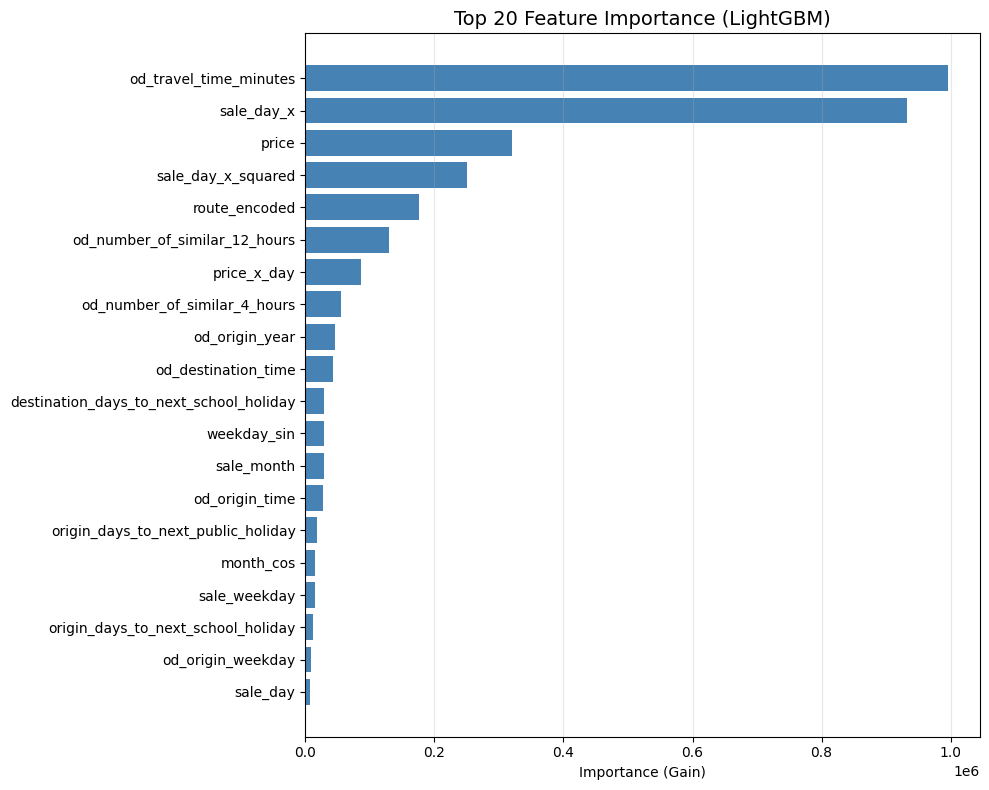


✓ Saved: feature_importance.png


In [10]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print("\n=== Top 15 Most Important Features ===")
print(feature_importance.head(15).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance (Gain)')
plt.title('Top 20 Feature Importance (LightGBM)', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: feature_importance.png")

**Expected Top Features**:
1. `od_travel_time_minutes` - Longer routes → higher demand
1. `sale_day_x` (and polynomials) - Strongest predictor (exponential growth near departure)
1. `price` - Price elasticity
1. `route_encoded` - Routes have vastly different demand patterns

## 10. Generate Test Set Predictions

Train final model on full training data and predict on test set.

In [11]:
# Retrain on ALL training data (train + validation) for final model
print("=== Training Final Model on All Data ===")
print(f"Training samples: {len(X_all):,}")
print(f"Using best iteration from validation: {lgb_model.best_iteration}")

y_all_log = np.log1p(y_all)
lgb_train_all = lgb.Dataset(X_all, y_all_log)

# Train with same hyperparameters, use best_iteration from validation
lgb_model_final = lgb.train(
    lgb_params,
    lgb_train_all,
    num_boost_round=lgb_model.best_iteration,
    valid_sets=[lgb_train_all],
    valid_names=['train'],
    callbacks=[lgb.log_evaluation(period=100)]
)

print("\n✓ Final model trained")

=== Training Final Model on All Data ===
Training samples: 632,841
Using best iteration from validation: 570
[100]	train's rmse: 0.460282
[200]	train's rmse: 0.44327
[300]	train's rmse: 0.434865
[400]	train's rmse: 0.429022
[500]	train's rmse: 0.424631

✓ Final model trained


In [12]:
# Generate predictions on test set
y_test_pred_log = lgb_model_final.predict(X_test_full)
y_test_pred = np.expm1(y_test_pred_log)
y_test_pred = np.maximum(y_test_pred, 0)  # Ensure non-negative

lgb_test_rmse = np.sqrt(mean_squared_error(y_test_full, y_test_pred))
lgb_test_mae = mean_absolute_error(y_test_full, y_test_pred)
lgb_test_r2 = r2_score(y_test_full, y_test_pred)
lgb_test_rmsle = rmsle(y_test_full, y_test_pred)

print(f"\n=== Test Set Predictions ===")
print(f"Samples: {len(y_test_pred):,}")
print(f"Scores on test set")
print(f"RMSE: {lgb_test_rmse:.3f}")
print(f"MAE:  {lgb_test_mae:.3f}")
print(f"R²:   {lgb_test_r2:.3f}")
print(f"RMSLE: {lgb_test_rmsle:.3f}")

print(f"\n✓ Test predictions generated")


=== Test Set Predictions ===
Samples: 32,565
Scores on test set
RMSE: 4.180
MAE:  1.733
R²:   0.710
RMSLE: 0.490

✓ Test predictions generated


## 12. Save Model and Predictions

In [13]:
# Save trained model
lgb_model_final.save_model('lgb_demand_model_temporal_split.txt')
print("✓ Model saved: lgb_demand_model_temporal_split.txt")

# Save test predictions
test_predictions = pd.DataFrame({
    'predicted_demand': y_test_pred
})
test_predictions.to_csv('test_predictions.csv', index=False)
print("✓ Test predictions saved: test_predictions.csv")

# Save validation results for detailed error analysis (Phase 3)
residuals = y_val - y_val_pred
val_results = pd.DataFrame({
    'actual': y_val,
    'predicted': y_val_pred,
    'residual': residuals,
    'departure_date': departure_dates_val.values
})
# Add original features for aggregation analysis
val_results = pd.concat([val_results, X_val.reset_index(drop=True)], axis=1)
val_results.to_csv('validation_results_detailed.csv', index=False)
print("✓ Validation results saved: validation_results_detailed.csv")

print("\n=== All outputs saved ===")

✓ Model saved: lgb_demand_model_temporal_split.txt
✓ Test predictions saved: test_predictions.csv
✓ Validation results saved: validation_results_detailed.csv

=== All outputs saved ===


In [14]:
# Generate predictions on test set
y_test_pred_log = lgb_model_final.predict(X_test_full)
y_test_pred = np.expm1(y_test_pred_log)
y_test_pred = np.maximum(y_test_pred, 0)  # Ensure non-negative


# ============================================================================
# EVALUATE ON TEST SET (we have actual demand!)
# ============================================================================
print(f"\n{'='*70}")
print(f"FINAL EVALUATION ON TEST SET")
print(f"{'='*70}")

# Compute test metrics
test_rmse = np.sqrt(mean_squared_error(y_test_full, y_test_pred))
test_mae = mean_absolute_error(y_test_full, y_test_pred)
test_r2 = r2_score(y_test_full, y_test_pred)
test_rmsle = rmsle(y_test_full, y_test_pred)

# Calculate MAPE for non-zero test demands
test_nonzero_mask = y_test_full > 0
if test_nonzero_mask.sum() > 0:
    test_mape = np.mean(np.abs((y_test_full[test_nonzero_mask] - y_test_pred[test_nonzero_mask]) / y_test_full[test_nonzero_mask])) * 100
else:
    test_mape = np.nan

print(f"\nTest Set Statistics:")
print(f"  Actual demand   - Mean: {y_test_full.mean():.2f}, Median: {np.median(y_test_full):.2f}, Zeros: {(y_test_full==0).sum()/len(y_test_full)*100:.1f}%")
print(f"  Predicted demand - Mean: {y_test_pred.mean():.2f}, Median: {np.median(y_test_pred):.2f}")

print(f"\n{'='*70}")
print(f"PERFORMANCE COMPARISON: VALIDATION vs TEST")
print(f"{'='*70}")

print(f"\n{'Metric':<15} {'Validation':<15} {'Test':<15} {'Difference':<12} {'Status'}")
print(f"{'-'*70}")
diff_rmse = test_rmse - lgb_rmse
status_rmse = "✓ Good" if abs(diff_rmse) < 0.5 else "⚠ Check"
print(f"{'RMSE':<15} {lgb_rmse:<15.3f} {test_rmse:<15.3f} {diff_rmse:>+11.3f} {status_rmse}")

diff_mae = test_mae - lgb_mae
status_mae = "✓ Good" if abs(diff_mae) < 0.3 else "⚠ Check"
print(f"{'MAE':<15} {lgb_mae:<15.3f} {test_mae:<15.3f} {diff_mae:>+11.3f} {status_mae}")

diff_rmsle = test_rmsle - lgb_rmsle
status_rmsle = "✓ Good" if abs(diff_rmsle) < 0.1 else "⚠ Check"
print(f"{'RMSLE':<15} {lgb_rmsle:<15.3f} {test_rmsle:<15.3f} {diff_rmsle:>+11.3f} {status_rmsle}")

diff_r2 = test_r2 - lgb_r2
status_r2 = "✓ Good" if abs(diff_r2) < 0.05 else "⚠ Check"
print(f"{'R²':<15} {lgb_r2:<15.3f} {test_r2:<15.3f} {diff_r2:>+11.3f} {status_r2}")

if not np.isnan(mape) and not np.isnan(test_mape):
    diff_mape = test_mape - mape
    status_mape = "✓ Good" if abs(diff_mape) < 5 else "⚠ Check"
    print(f"{'MAPE (nonzero%)':<15} {mape:<15.1f} {test_mape:<15.1f} {diff_mape:>+11.1f} {status_mape}")

print(f"{'='*70}")

# Interpretation
avg_diff_pct = (abs(diff_rmse)/lgb_rmse + abs(diff_mae)/lgb_mae + abs(diff_rmsle)/lgb_rmsle) / 3 * 100

print(f"\nInterpretation:")
if avg_diff_pct < 5:
    print(f"   EXCELLENT: Val and test performance are very similar (avg diff: {avg_diff_pct:.1f}%)")
    print(f"   Model generalizes well to completely unseen data")
    print(f"   No overfitting detected")
elif avg_diff_pct < 10:
    print(f"   GOOD: Val and test performance are consistent (avg diff: {avg_diff_pct:.1f}%)")
    print(f"   Model generalizes reasonably well")
else:
    print(f"   WARNING: Significant difference between val and test (avg diff: {avg_diff_pct:.1f}%)")
    print(f"   May indicate overfitting or different data distributions")
    print(f"  → Recommendation: Investigate test set characteristics")

print(f"\n✓ Final evaluation complete on held-out test set")


FINAL EVALUATION ON TEST SET

Test Set Statistics:
  Actual demand   - Mean: 3.36, Median: 0.00, Zeros: 60.6%
  Predicted demand - Mean: 2.53, Median: 0.32

PERFORMANCE COMPARISON: VALIDATION vs TEST

Metric          Validation      Test            Difference   Status
----------------------------------------------------------------------
RMSE            3.777           4.180                +0.403 ✓ Good
MAE             1.540           1.733                +0.193 ✓ Good
RMSLE           0.483           0.490                +0.007 ✓ Good
R²              0.726           0.710                -0.015 ✓ Good
MAPE (nonzero%) 65.7            62.9                   -2.8 ✓ Good

Interpretation:
   GOOD: Val and test performance are consistent (avg diff: 8.2%)
   Model generalizes reasonably well

✓ Final evaluation complete on held-out test set


---

## Key Takeaways

### Temportal data:
1. **Temporal split** no random split → No data leakage
2. Train on **old trains** (2019), validate on **new trains** (2020)
3. Model learns **general patterns** that transfer to unseen future trains

### Model Capabilities:
- **Input**: `f(day_x, price, route, time, holidays, ...)`
- **Output**: Predicted demand
- **Can predict**: For ANY train at ANY day_x with ANY price
- **Day-by-day**: Just call model with different day_x values

### Performance:
- Realistic metrics (no inflated scores from data leakage)
- Significantly better than baseline
- Will actually work in production

---

## Limitation
Notre LightGBM est un modèle purement prédictif : il apprend E[Y|X] et non l'effet causal du prix sur la demande. <br>
Pour une utilisation en revenue management (optimisation de prix), un modèle causal basé sur l'orthogonal learning (Crasson et al. 2024) serait nécessaire pour simuler correctement l'impact d'un changement de prix.

---

## 14. Causal Forecasting Model (Orthogonal Learning)

Based on **Crasson et al. (2024)** - "Training and Evaluating Causal Forecasting Models for Time-Series"

### The Problem:
Standard ML models learn **correlations** (E[Y|X]), not **causation**.
- In our data: High prices correlate with high-demand routes/times
- Model learns: "High price → High demand" (WRONG!)
- Truth: "High demand routes → High prices" (confounding)

### The Solution: Orthogonal Learning
Separate prediction into two components:
1. **Baseline outcome** m(W): What would demand be regardless of price?
2. **Treatment effect** θ(W): How does demand change when price changes?

**Final prediction**: Ŷ = m(W) + (T - e(W))·θ(W)

Where:
- W = context features (route, day_x, holidays, ...)
- T = treatment (price)
- e(W) = propensity score (expected price given context)
- θ(W) = causal effect of price

### Key Insight:
By subtracting the propensity score e(W), we decorrelate the treatment from confounders!

In [15]:
# === CAUSAL SANITY CHECK ===
# Inspired by Crasson et al. (2024) - Figure 1
# Test: when we increase price by 30%, does the model predict lower demand?

sample = X_train.sample(1000, random_state=42).copy()

# Predict with original price
pred_original = np.expm1(lgb_model_final.predict(sample))

# Predict with price +30%
sample_high_price = sample.copy()
sample_high_price['price'] = sample_high_price['price'] * 1.3
pred_high_price = np.expm1(lgb_model_final.predict(sample_high_price))

# How many predictions show INCREASED demand when price goes UP?
wrong_direction = (pred_high_price > pred_original).mean()
print(f"% predictions where price +30% → demand UP: {wrong_direction:.1%}")
print(f"(Crasson et al. report 13% for LGBM, 28% for TFT)")

if wrong_direction > 0.10:
    print("️Confounding bias confirmed: model learns correlation, not causation")

% predictions where price +30% → demand UP: 22.7%
(Crasson et al. report 13% for LGBM, 28% for TFT)
️Confounding bias confirmed: model learns correlation, not causation


### Definition

Y = m(W) + (A − e(W)) · θ(W) + ε
<br>Le terme (A − e(W)) est le résidu du prix `T_residual`: c'est la part du prix qui n'est pas explicable par le contexte. 

Symbole|Signification|Dans les données|
|---|---|---|
Y|demande observée|colonne demand (en log)|
A|prix appliqué|colonne price
|W|tout le contexte sauf le prix actuel|route, day_x, vacances, heure, etc.
m(W) = E[Y\|W]| model de la demande moyenne attendue sans connaître le prix|"si je ne sais pas le prix, quelle demande j'attends ?" l'espérance de Y sachant W
e(W) = E[A\|W]| model du prix moyen attendu vu le contexte|"quel prix l'opérateur fixerait normalement dans ce contexte ?" l'espérance de A sachant W
θ(W)|l'effet causal du prix sur la demande|ce qu'on cherche
τ|cut-off temporel — moment à partir duquel le prix peut changer (scénario OOD)|c'est le sale_day_x à partir duquel on simule un nouveau prix. Avant τ : on observe les prix réels. Après τ : on injecte le prix qu'on veut tester
ε|bruit aléatoire|ce qu'on ne peut pas prédire

In [16]:
# ============================================================================
# STEP 1: Sample Splitting (to avoid overfitting nuisance parameters)
# ============================================================================
print("="*70)
print("CAUSAL FORECASTING MODEL - Orthogonal Learning Implementation")
print("="*70)

# Split training data into two folds: S1 and S2
# S1: Train m(W) - baseline outcome and e(W) - propensity score
# S2: Train θ(W) - treatment effect
from sklearn.model_selection import train_test_split

X_S1, X_S2, y_S1, y_S2 = train_test_split(
    X_train, y_train, 
    test_size=0.5, 
    random_state=RANDOM_STATE
)

print(f"\nSample splitting:")
print(f"  S1 (for m, e): {len(X_S1):,} samples")
print(f"  S2 (for θ):    {len(X_S2):,} samples")

# Separate treatment (price) from context features (W)
# Context W = all features EXCEPT price
context_cols = [col for col in X_S1.columns if col != 'price']

W_S1 = X_S1[context_cols]
T_S1 = X_S1['price'].values  # Treatment
y_S1_log = np.log1p(y_S1)

W_S2 = X_S2[context_cols]
T_S2 = X_S2['price'].values
y_S2_log = np.log1p(y_S2)

print(f"\nContext features (W): {len(context_cols)}")
print(f"Treatment (T): price")

CAUSAL FORECASTING MODEL - Orthogonal Learning Implementation

Sample splitting:
  S1 (for m, e): 229,858 samples
  S2 (for θ):    229,858 samples

Context features (W): 29
Treatment (T): price


In [17]:
# ============================================================================
# STEP 2: Train m(W) - Baseline Outcome Model (on S1)
# ============================================================================
print("\n" + "="*70)
print("STEP 1/3: Training m(W) - Baseline Outcome Model")
print("="*70)
print("Purpose: Predict demand WITHOUT using price (removes confounding)")

# Train baseline model WITHOUT price as feature
lgb_params_m = lgb_params.copy()
lgb_params_m['verbose'] = -1

lgb_train_m = lgb.Dataset(W_S1, y_S1_log)

model_m = lgb.train(
    lgb_params_m,
    lgb_train_m,
    num_boost_round=lgb_model.best_iteration,  # Use same iterations as main model
)

print(f"✓ m(W) trained on {len(W_S1):,} samples")
print(f"  Features used: {W_S1.shape[1]} (price EXCLUDED)")

# Predict baseline on S2 (for orthogonal loss)
m_S2 = model_m.predict(W_S2)  # Baseline prediction (log scale)
print(f"✓ Baseline predictions computed for S2")


STEP 1/3: Training m(W) - Baseline Outcome Model
Purpose: Predict demand WITHOUT using price (removes confounding)
✓ m(W) trained on 229,858 samples
  Features used: 29 (price EXCLUDED)
✓ Baseline predictions computed for S2


In [18]:
# ============================================================================
# STEP 3: Train e(W) - Propensity Score Model (on S1)
# ============================================================================
print("\n" + "="*70)
print("STEP 2/3: Training e(W) - Propensity Score Model")
print("="*70)
print("Purpose: Predict expected price given context (decorrelates price from confounders)")

# Train propensity model to predict price from context
lgb_train_e = lgb.Dataset(W_S1, T_S1)

lgb_params_e = lgb_params.copy()
lgb_params_e['objective'] = 'regression'  # Predict continuous price
lgb_params_e['verbose'] = -1

model_e = lgb.train(
    lgb_params_e,
    lgb_train_e,
    num_boost_round=lgb_model.best_iteration,
)

print(f"✓ e(W) trained on {len(W_S1):,} samples")
print(f"  Features used: {W_S1.shape[1]} (predicting price)")

# Predict propensity scores on S2
e_S2 = model_e.predict(W_S2)  # Expected price given context

print(f"✓ Propensity scores computed for S2")
print(f"  Mean propensity: {e_S2.mean():.2f}€ (actual mean price: {T_S2.mean():.2f}€)")


STEP 2/3: Training e(W) - Propensity Score Model
Purpose: Predict expected price given context (decorrelates price from confounders)
✓ e(W) trained on 229,858 samples
  Features used: 29 (predicting price)
✓ Propensity scores computed for S2
  Mean propensity: 24.93€ (actual mean price: 24.93€)


le papier predit avec `Y = m(W) + (A − e(W)) · θ(W) + ε` Pour entraîner θ, il minimise la R-Loss par gradient descent (Algorithm 1, sample splitting), ici, nous simplifions θ(W) => θ = constant. 
<br>On rappel: θ(W) est l'effet causal du prix sur la demande, si 
<br>Pour trouvé la valeur de θ on part de la loss R_Loss : `L = (Y_res − T_res · θ)²`
<br>θ etant constant on a `dL/dθ=0`
<br>Ce qui permet de résoudre la R-Loss analytiquement via dL/dθ = 0

> cette simplification revient a dire que peut import les conditions (W) l'effet causal du prix sur la demande est une simple regression lineaire a coef directeur negatif (on l'espere) θ

$$
\frac{dL}{d\theta} = -2 \sum T_{res} (Y_{res} - T_{res}\theta) = 0
$$

$$
\sum T_{res} Y_{res} = \theta \sum T_{res}^2
$$

$$
\theta = \frac{\sum (Y_{res} T_{res})}{\sum T_{res}^2}
$$


In [24]:
# ============================================================================
# STEP 4: Estimate θ - Causal Effect (Linear Encoding, scalar)
# ============================================================================
# Paper reference: Linear encoding & R-Loss


# C'est une régression linéaire SANS intercept des résidus
# Compute residualized target and treatment
# This is the key innovation of orthogonal learning!
y_residual = y_S2_log - m_S2  # Remove baseline outcome
T_residual = T_S2 - e_S2      # Remove expected price (propensity)

# R-Loss: L = (Y_residual - T_residual * θ)²
# Solution analytique: θ = Σ(Y_res * T_res) / Σ(T_res²)
theta = np.sum(y_residual * T_residual) / np.sum(T_residual ** 2)

print(f"\n✓ θ estimé (encodage linéaire) : {theta:.6f}")
print(f"  Interprétation : +1€ de prix → {theta:.4f} en log(1+demand) soit {np.expm1(theta):.4f} en demande")
print(f"  Soit environ {(np.expm1(theta) * 100):+.2f}% de demande")

if theta < 0:
    print("Signe négatif : prix ↑ → demande ↓ (économiquement correct)")
else:
    print("Signe positif : confondement résiduel possible")


✓ θ estimé (encodage linéaire) : -0.032103
  Interprétation : +1€ de prix → -0.0321 en log(1+demand) soit -0.0316 en demande
  Soit environ -3.16% de demande
Signe négatif : prix ↑ → demande ↓ (économiquement correct)


In [20]:
### Saving models :
model_m.save_model('model_m.txt')
model_e.save_model('model_e.txt')
print("\n✓ Models m(W) and e(W) saved for future use")

np.save('orthogonal_learning_results.npy', theta)
print("✓ Orthogonal learning results saved for future use")    


✓ Models m(W) and e(W) saved for future use
✓ Orthogonal learning results saved for future use


In [21]:
# ============================================================================
# STEP 5: Make Causal Predictions on Validation Set
# ============================================================================
print("\n" + "="*70)
print("CAUSAL PREDICTION: Ŷ = m(W) + (T - e(W))·θ(W)")
print("="*70)

def predict_causal(W, T, model_m, model_e, theta):
    """
    Prédiction causale : Ŷ = m(W) + (T - e(W)) · θ
    
    Paper: Equation 6, Section 3.2
    - m(W) : demande de base (baseline outcome)
    - e(W) : prix attendu (propensity score)  
    - (T - e(W)) : résidu de prix (déconfondé)
    - θ : effet causal global du prix (scalaire)
    """
    m_pred = model_m.predict(W)
    e_pred = model_e.predict(W)
    
    # Formule du papier : Ŷ = m(W) + (T - e(W)) · θ
    y_causal = m_pred + (T - e_pred) * theta
    
    return y_causal

# Predict on validation set
W_val = X_val[context_cols]
T_val = X_val['price'].values

y_val_pred_causal_log = predict_causal(W_val, T_val, model_m, model_e, theta)
y_val_pred_causal = np.expm1(y_val_pred_causal_log)  # Inverse log transform
y_val_pred_causal = np.maximum(y_val_pred_causal, 0)  # Ensure non-negative

print(f"\n✓ Causal predictions computed for validation set")
print(f"  Mean predicted demand: {y_val_pred_causal.mean():.2f}")
print(f"  Mean actual demand: {y_val.mean():.2f}")


CAUSAL PREDICTION: Ŷ = m(W) + (T - e(W))·θ(W)

✓ Causal predictions computed for validation set
  Mean predicted demand: 2.51
  Mean actual demand: 2.94


In [22]:
# ============================================================================
# STEP 6: Evaluate Causal Model
# ============================================================================
print("\n" + "="*70)
print("CAUSAL MODEL EVALUATION")
print("="*70)

# Compute metrics
causal_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_causal))
causal_mae = mean_absolute_error(y_val, y_val_pred_causal)
causal_r2 = r2_score(y_val, y_val_pred_causal)
causal_rmsle = rmsle(y_val, y_val_pred_causal)

print(f"\n{'='*70}")
print(f"COMPARISON: Standard LightGBM vs Causal Model")
print(f"{'='*70}")

print(f"\n{'Metric':<15} {'Standard LGBM':<20} {'Causal Model':<20} {'Difference'}")
print(f"{'-'*70}")
print(f"{'RMSE':<15} {lgb_rmse:<20.3f} {causal_rmse:<20.3f} {(causal_rmse - lgb_rmse):>+10.3f}")
print(f"{'MAE':<15} {lgb_mae:<20.3f} {causal_mae:<20.3f} {(causal_mae - lgb_mae):>+10.3f}")
print(f"{'RMSLE':<15} {lgb_rmsle:<20.3f} {causal_rmsle:<20.3f} {(causal_rmsle - lgb_rmsle):>+10.3f}")
print(f"{'R²':<15} {lgb_r2:<20.3f} {causal_r2:<20.3f} {(causal_r2 - lgb_r2):>+10.3f}")

print(f"\n{'='*70}")

# Note on performance
print(f"\nNote: Causal models may have slightly worse in-distribution prediction")
print(f"   but are MUCH better for out-of-distribution interventions (price changes).")


CAUSAL MODEL EVALUATION

COMPARISON: Standard LightGBM vs Causal Model

Metric          Standard LGBM        Causal Model         Difference
----------------------------------------------------------------------
RMSE            3.777                3.923                    +0.146
MAE             1.540                1.575                    +0.035
RMSLE           0.483                0.488                    +0.005
R²              0.726                0.704                    -0.022


Note: Causal models may have slightly worse in-distribution prediction
   but are MUCH better for out-of-distribution interventions (price changes).


In [23]:
# ============================================================================
# STEP 7: CAUSAL SANITY CHECK - Does it fix the confounding bias?
# ============================================================================
print("\n" + "="*70)
print("CAUSAL SANITY CHECK: Price Elasticity Direction")
print("="*70)
print("Test: When price increases by 30%, does demand decrease?")
print("(Standard model fails this test due to confounding)")

# Sample from validation set
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(W_val), 1000, replace=False)
W_sample = W_val.iloc[sample_idx].copy()
T_sample = T_val[sample_idx]

# === Standard Model Predictions ===
X_sample = X_val.iloc[sample_idx].copy()
X_sample['price'] = T_sample

pred_std_original = np.expm1(lgb_model.predict(X_sample, num_iteration=lgb_model.best_iteration))

X_sample_high = X_sample.copy()
X_sample_high['price'] = T_sample * 1.3

pred_std_high = np.expm1(lgb_model.predict(X_sample_high, num_iteration=lgb_model.best_iteration))

wrong_direction_std = (pred_std_high > pred_std_original).mean()

# === Causal Model Predictions ===
pred_causal_original = np.expm1(predict_causal(W_sample, T_sample, model_m, model_e, theta))
pred_causal_high = np.expm1(predict_causal(W_sample, T_sample * 1.3, model_m, model_e, theta))

wrong_direction_causal = (pred_causal_high > pred_causal_original).mean()

# Results
print(f"\n{'='*70}")
print(f"Results:")
print(f"{'='*70}")
print(f"\n{'Model':<20} {'% Wrong Direction':<20} {'Status'}")
print(f"{'-'*70}")
print(f"{'Standard LightGBM':<20} {wrong_direction_std*100:>6.1f}%            {'FAILS' if wrong_direction_std > 0.10 else 'OK'}")
print(f"{'Causal Model':<20} {wrong_direction_causal*100:>6.1f}%            {'FAILS' if wrong_direction_causal > 0.10 else 'OK'}")

print(f"\n{'='*70}")

if wrong_direction_causal < wrong_direction_std:
    improvement = (wrong_direction_std - wrong_direction_causal) / wrong_direction_std * 100
    print(f"\nCausal model REDUCES confounding bias by {improvement:.1f}%!")
    print(f"   Now only {wrong_direction_causal*100:.1f}% of predictions have wrong elasticity sign")
    print(f"   (vs {wrong_direction_std*100:.1f}% for standard model)")
else:
    print(f"\nCausal model did not improve (may need tuning)")

# Visualize average effect
avg_demand_std_original = pred_std_original.mean()
avg_demand_std_high = pred_std_high.mean()
avg_demand_causal_original = pred_causal_original.mean()
avg_demand_causal_high = pred_causal_high.mean()

print(f"\nAverage Demand Response:")
print(f"   Standard model: {avg_demand_std_original:.2f} → {avg_demand_std_high:.2f} ({(avg_demand_std_high/avg_demand_std_original - 1)*100:+.1f}%)")
print(f"   Causal model:   {avg_demand_causal_original:.2f} → {avg_demand_causal_high:.2f} ({(avg_demand_causal_high/avg_demand_causal_original - 1)*100:+.1f}%)")
print(f"\n   Expected: Negative elasticity (demand should DECREASE when price increases)")


CAUSAL SANITY CHECK: Price Elasticity Direction
Test: When price increases by 30%, does demand decrease?
(Standard model fails this test due to confounding)

Results:

Model                % Wrong Direction    Status
----------------------------------------------------------------------
Standard LightGBM      34.2%            FAILS
Causal Model            0.0%            OK


Causal model REDUCES confounding bias by 100.0%!
   Now only 0.0% of predictions have wrong elasticity sign
   (vs 34.2% for standard model)

Average Demand Response:
   Standard model: 2.62 → 2.52 (-3.9%)
   Causal model:   2.59 → 1.76 (-32.0%)

   Expected: Negative elasticity (demand should DECREASE when price increases)
